Evolutionary Algorithm on: debug_10.txt (10 items)
Hyperparameters: Population=50, Generations=500
Best price found: 295



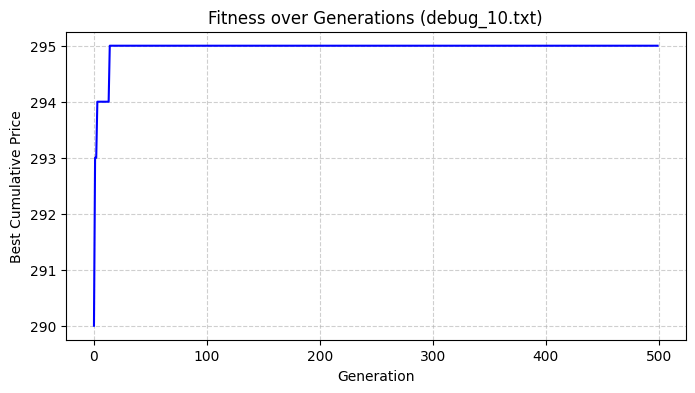




Evolutionary Algorithm on: debug_20.txt (20 items)
Hyperparameters: Population=50, Generations=500
Best price found: 1024



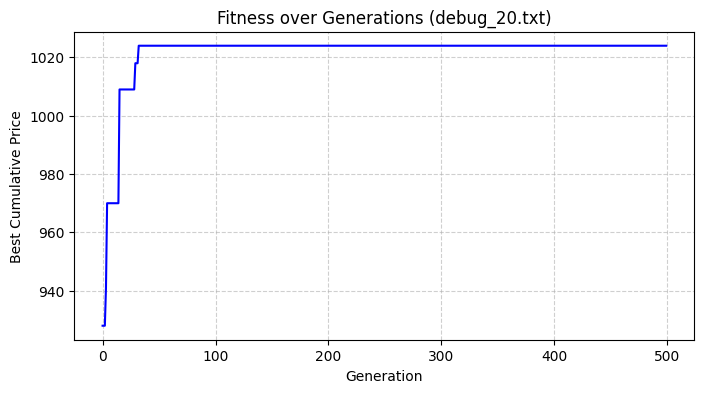




Evolutionary Algorithm on: input_100.txt (100 items)
Hyperparameters: Population=200, Generations=1000
Best price found: 9147



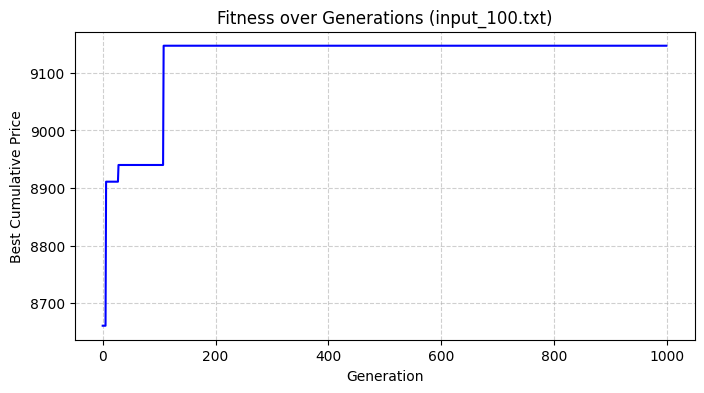




Evolutionary Algorithm on: input_1000.txt (1000 items)
Hyperparameters: Population=300, Generations=1500
Best price found: 54485



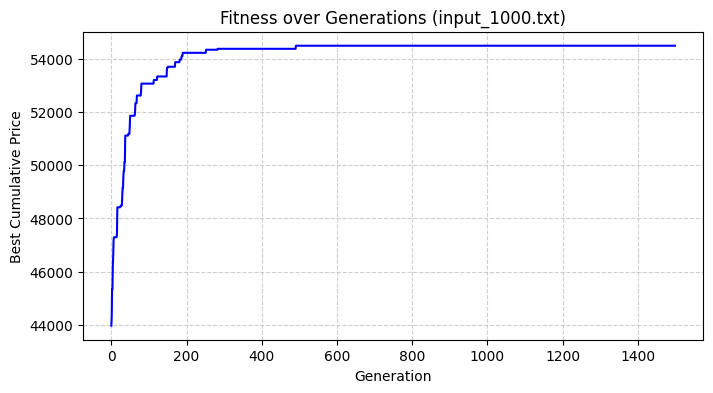

In [ ]:
%matplotlib inline
import random
import copy
import matplotlib.pyplot as plt

PRICES = []
WEIGHTS = []
CAPACITY = 0

def load_data(filename):
    global PRICES, WEIGHTS, CAPACITY
    with open(filename, 'r') as f:
        lines = f.readlines()

    n, CAPACITY = map(int, lines[0].strip().split())

    PRICES = []
    WEIGHTS = []
    for line in lines[1:n+1]:
        c, w = map(int, line.strip().split())
        PRICES.append(c)
        WEIGHTS.append(w)
    return n

def knapsack_fitness(ind):
    s_price = sum(i * p for (i, p) in zip(ind, PRICES))
    s_weight = sum(i * w for (i, w) in zip(ind, WEIGHTS))
    if s_weight > CAPACITY:
        return 0.0001
    return s_price

def repair(ind):
    s_weight = sum(i * w for (i, w) in zip(ind, WEIGHTS))

    while s_weight > CAPACITY:
        in_bag = [idx for idx, val in enumerate(ind) if val == 1]
        if not in_bag:
            break

        drop_idx = min(in_bag, key=lambda idx: PRICES[idx] / WEIGHTS[idx])

        ind[drop_idx] = 0
        s_weight -= WEIGHTS[drop_idx]

    return ind

def random_individual(dim):
    ind = [random.randint(0,1) for _ in range(dim)]
    return repair(ind)

def random_population(pop_size, dim):
    return [random_individual(dim) for _ in range(pop_size)]

def select(pop, how_many, fits):
    sel = random.choices(pop, weights=fits, k=how_many)
    return copy.deepcopy(sel)

def crossover(pool, cross_p):
    dim = len(pool[0])
    off = []
    for p1, p2 in zip(pool[::2], pool[1::2]):
        if random.random() < cross_p:
            point = random.randrange(0, dim)
            o1 = p1[:point] + p2[point:]
            o2 = p2[:point] + p1[point:]
        else:
            o1, o2 = p1, p2
        off += [o1, o2]
    return off

def mutation(pool, mut_p, flip_p):
    off = []
    for p in pool:
        if random.random() < mut_p:
            o = []
            for v in p:
                if random.random() < flip_p:
                    o.append(1-v)
                else:
                    o.append(v)
            off.append(o)
        else:
            off.append(p)
    return off

def evolution(pop, dim, fitness, max_gen, cross_p, mut_p, flip_p):
    pop_size = len(pop)
    log = []
    for g in range(max_gen):
        fits = [fitness(ind) for ind in pop]
        log.append(max(fits))

        best = max(pop, key=fitness)

        mating_pool = select(pop, pop_size, fits)
        pre_off = crossover(mating_pool, cross_p)
        off = mutation(pre_off, mut_p, flip_p)

        off = [repair(child) for child in off]

        off[0] = copy.deepcopy(best)
        pop = off
    return pop, log


if __name__ == "__main__":

    files_to_run = {
        "debug_10.txt":   {"POP_SIZE": 50,  "MAX_GEN": 500},
        "debug_20.txt":   {"POP_SIZE": 50,  "MAX_GEN": 500},
        "input_100.txt":  {"POP_SIZE": 200, "MAX_GEN": 1000},
        "input_1000.txt": {"POP_SIZE": 300, "MAX_GEN": 1500}
    }

    for target_file, params in files_to_run.items():
        DIM = load_data(target_file)

        POP_SIZE = params["POP_SIZE"]
        MAX_GEN = params["MAX_GEN"]
        CROSS_P = 0.8
        MUT_P = 0.2
        FLIP_P = 1.0 / DIM

        print(f"Evolutionary Algorithm on: {target_file} ({DIM} items)")
        print(f"Hyperparameters: Population={POP_SIZE}, Generations={MAX_GEN}")

        pop = random_population(POP_SIZE, DIM)
        res, log = evolution(pop, DIM, knapsack_fitness, MAX_GEN, CROSS_P, MUT_P, FLIP_P)

        best_ind = max(res, key=knapsack_fitness)
        best_price = knapsack_fitness(best_ind)

        print(f"Best price found: {round(best_price)}\n")

        plt.figure(figsize=(8, 4))
        plt.plot(log, color='blue')
        plt.title(f'Fitness over Generations ({target_file})')
        plt.xlabel('Generation')
        plt.ylabel('Best Cumulative Price')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()
        print("\n\n")

**Description of the Algorithm:**

I implemented the evolutionary algorithm to solve the Knapsack problem. I mainly used the codes and structures from the Simple Genetic Algorithm class exercises.

**Encoding of Individuals:**

I represented the solutions as binary strings of length n. A value of 1 indicates that the corresponding object is included in the knapsack, while a 0 indicates it is excluded.

**Fitness Function and Repair Mechanism:**

The aim is to maximize the cumulative price. The fitness function calculates the sum of the prices of the selected items. If the total weight of the selected items exceeds the knapsack capacity W, the solution is invalid, and a severe penalty is applied

However, to improve the algorithm's performance, I implemented a repair function. If an individual is over the capacity, the repair function fixes it by identifying and dropping the items with the lowest price-to-weight ratio one by one until weight is back under the limit.

**Selection Method:**

I selected the individuals form a mating pool with a probability proportional to their fitness scores.

**Genetic Operators: * Crossover:**

I applied a single-point crossover. Code recombined pairs of parents at a randomly selected split point to create two offspring, evaluated by the crossover probability (CROSS_P).

- Mutation: Also applied a bit-flip mutation.If an offspring is selected for the mutation, each bit in its chromosome has a probability of flipping from 0 to 1 or 1 to 0

The algorithm is implemented in Python

Steps

Since I am using the Jupyter Notebook all the .txt files must be placed in the same directory as the .ipynb notebook.

User must change the target_file variable to the desired input text file to run the code according to the inputs

After running the code, the script will output the best cumulative price discovered and input a matplotlib graph showing the fitness progression over the generations

Evaluation Criteria and Discovered Solutions
To verify the correctness of the implementation, I run the algorithm in provided debug files using the hyperparameters given in the practical labs

POP_SIZE: 50
MAX_GEN: 500
CROSS_P: 0.8
MUT_P: 0.2
Under these settings I algorithm produced:

debug_10.txt: Found the optimal price of 295

debug_20.txt: Found the optimal price of 1024

input_100.txt: Found the optimal price of 9147

input_1000.txt: Found the optimal price of 54485